                        Project : Customer Churn Dataset

                                                    Submitted by,
                                                    Aksa Anna Jose



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, confusion_matrix, accuracy_score

In [2]:
# Load Dataset
df = pd.read_csv('/content/customer_churn.csv')

Step 1: Data Manipulation Tasks

In [3]:
# Extract the 5th column (Index 4)
customer_5 = df.iloc[:, 4]

# Extract the 15th column (Index 14)
customer_15 = df.iloc[:, 14]

# Extract all male senior citizens whose payment method is electronic check
senior_male_electronic = df[(df['gender'] == 'Male') &
                            (df['SeniorCitizen'] == 1) &
                            (df['PaymentMethod'] == 'Electronic check')]

# Extract customers whose tenure is > 70 months or monthly charges > $100
customer_total_tenure = df[(df['tenure'] > 70) | (df['MonthlyCharges'] > 100)]

# Extract customers with a two-year contract, mailed check payment method, and Churn is 'Yes'
two_mail_yes = df[(df['Contract'] == 'Two year') &
                  (df['PaymentMethod'] == 'Mailed check') &
                  (df['Churn'] == 'Yes')]

# Extract 333 random records
customer_333 = df.sample(n=333, random_state=42)

# Get the count of different levels from the 'Churn' column
churn_counts = df['Churn'].value_counts()

print("Churn Counts:\n", churn_counts)

Churn Counts:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64


Step 2: Data Visualization

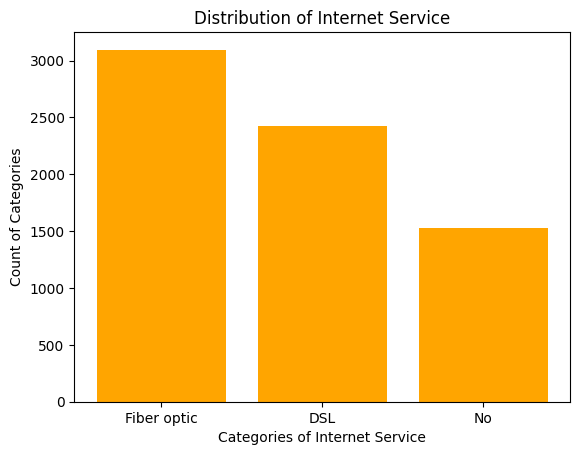

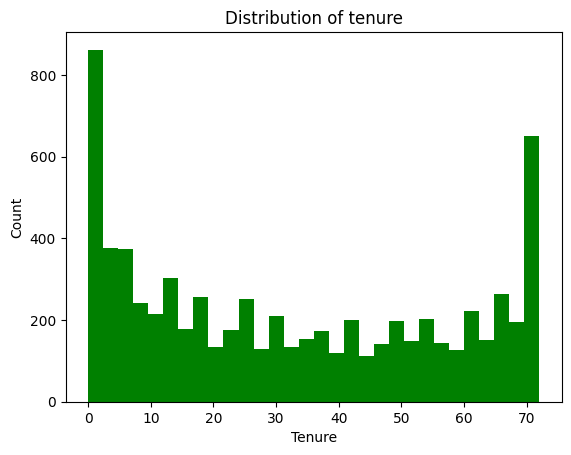

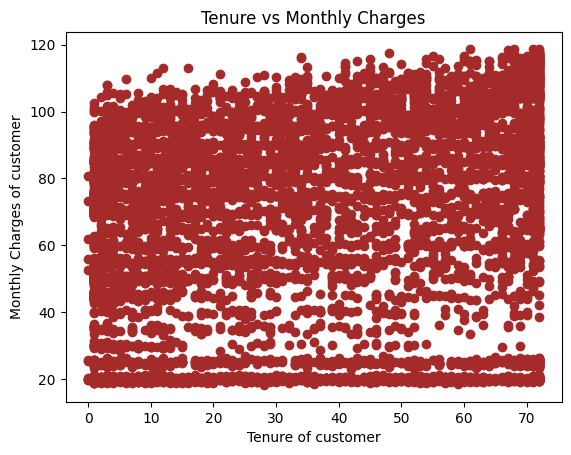

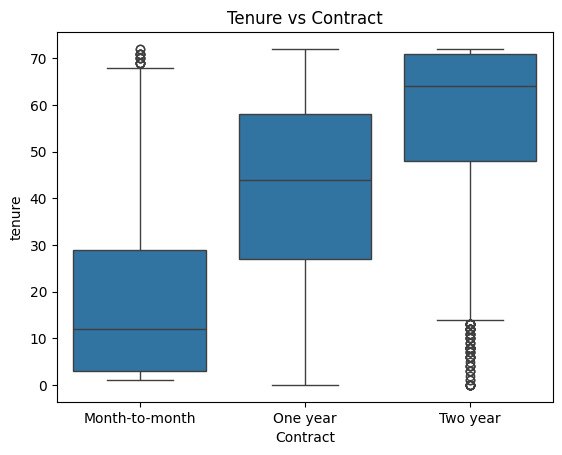

In [4]:
# 1. Bar-plot for the 'InternetService' column
internet_counts = df['InternetService'].value_counts()
plt.bar(internet_counts.index, internet_counts.values, color='orange')
plt.xlabel('Categories of Internet Service')
plt.ylabel('Count of Categories')
plt.title('Distribution of Internet Service')
plt.show()

# 2. Histogram for the 'tenure' column
plt.hist(df['tenure'], bins=30, color='green')
plt.title('Distribution of tenure')
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.show()

# 3. Scatter-plot between 'MonthlyCharges' and 'tenure'
plt.scatter(df['tenure'], df['MonthlyCharges'], color='brown')
plt.xlabel('Tenure of customer')
plt.ylabel('Monthly Charges of customer')
plt.title('Tenure vs Monthly Charges')
plt.show()

# 4. Box-plot between 'tenure' & 'Contract'
sns.boxplot(x='Contract', y='tenure', data=df)
plt.title('Tenure vs Contract')
plt.show()

Step 3: Linear Regression Model

In [5]:
# Independent variable (X) and Dependent variable (y)
X3 = df[['tenure']]
y3 = df['MonthlyCharges']

# Split dataset into 70:30 train/test ratio
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.30, random_state=42)

# Build and fit the model
lr = LinearRegression()
lr.fit(X3_train, y3_train)

# Predict values
y3_pred = lr.predict(X3_test)

# Find prediction error and Root Mean Square Error (RMSE)
error = y3_test - y3_pred
rmse3 = np.sqrt(mean_squared_error(y3_test, y3_pred))

print(f"Linear Regression RMSE: {rmse3:.4f}")

Linear Regression RMSE: 29.0794


Step 4: Logistic Regression Models

In [7]:
# --- A. Simple Logistic Regression ---
X4_s = df[['MonthlyCharges']]
y4_s = df['Churn']

# Split dataset into 65:35 ratio
X4_s_train, X4_s_test, y4_s_train, y4_s_test = train_test_split(X4_s, y4_s, test_size=0.35, random_state=42)

log_s = LogisticRegression()
log_s.fit(X4_s_train, y4_s_train)
y4_s_pred = log_s.predict(X4_s_test)

print("Simple Logistic Regression Confusion Matrix:\n", confusion_matrix(y4_s_test, y4_s_pred))
print(f"Simple Logistic Regression Accuracy: {accuracy_score(y4_s_test, y4_s_pred):.4f}\n")


# --- B. Multiple Logistic Regression ---
X4_m = df[['tenure', 'MonthlyCharges']]
y4_m = df['Churn']

# Split dataset into 80:20 ratio
X4_m_train, X4_m_test, y4_m_train, y4_m_test = train_test_split(X4_m, y4_m, test_size=0.20, random_state=42)

log_m = LogisticRegression()
log_m.fit(X4_m_train, y4_m_train)
y4_m_pred = log_m.predict(X4_m_test)

print("Multiple Logistic Regression Confusion Matrix:\n", confusion_matrix(y4_m_test, y4_m_pred))
print(f"Multiple Logistic Regression Accuracy: {accuracy_score(y4_m_test, y4_m_pred):.4f}")

Simple Logistic Regression Confusion Matrix:
 [[1797    0]
 [ 669    0]]
Simple Logistic Regression Accuracy: 0.7287

Multiple Logistic Regression Confusion Matrix:
 [[944  92]
 [193 180]]
Multiple Logistic Regression Accuracy: 0.7977


Step 5: Decision Tree Model

In [6]:
X5 = df[['tenure']]
y5 = df['Churn']

# Split dataset into 80:20 ratio
X5_train, X5_test, y5_train, y5_test = train_test_split(X5, y5, test_size=0.20, random_state=42)

# Build and fit Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X5_train, y5_train)
y5_pred = dt.predict(X5_test)

print("Decision Tree Confusion Matrix:\n", confusion_matrix(y5_test, y5_pred))
print(f"Decision Tree Accuracy: {accuracy_score(y5_test, y5_pred):.4f}")

Decision Tree Confusion Matrix:
 [[951  85]
 [257 116]]
Decision Tree Accuracy: 0.7573


Step 6: Random Forest Model

In [8]:
X6 = df[['tenure', 'MonthlyCharges']]
y6 = df['Churn']

# Split dataset into 70:30 ratio
X6_train, X6_test, y6_train, y6_test = train_test_split(X6, y6, test_size=0.30, random_state=42)

# Build and fit Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X6_train, y6_train)
y6_pred = rf.predict(X6_test)

print("Random Forest Confusion Matrix:\n", confusion_matrix(y6_test, y6_pred))
print(f"Random Forest Accuracy: {accuracy_score(y6_test, y6_pred):.4f}")

Random Forest Confusion Matrix:
 [[1341  198]
 [ 308  266]]
Random Forest Accuracy: 0.7605
